## Pumpkin Varieties and Color

Load up required libraries and dataset. Convert the data to a dataframe containing a subset of the data: 

Let's look at the relationship between color and variety

In [185]:
import pandas as pd
import numpy as np

full_pumpkins = pd.read_csv('../data/US-pumpkins.csv')

full_pumpkins.head()

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
0,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,4/29/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
1,BALTIMORE,NaN,24 inch bins,NaN,NaN,NaN,5/6/17,270.0,280.0,270.0,...,NaN,NaN,NaN,NaN,NaN,NaN,E,NaN,NaN,NaN
2,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
3,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,9/24/16,160.0,160.0,160.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
4,BALTIMORE,NaN,24 inch bins,HOWDEN TYPE,NaN,NaN,11/5/16,90.0,100.0,90.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [186]:
# Veri setindeki tüm sütun isimlerini listeleme
print(full_pumpkins.columns.tolist())

['City Name', 'Type', 'Package', 'Variety', 'Sub Variety', 'Grade', 'Date', 'Low Price', 'High Price', 'Mostly Low', 'Mostly High', 'Origin', 'Origin District', 'Item Size', 'Color', 'Environment', 'Unit of Sale', 'Quality', 'Condition', 'Appearance', 'Storage', 'Crop', 'Repack', 'Trans Mode', 'Unnamed: 24', 'Unnamed: 25']


In [187]:
# Sadece gerekli sütunları seçme
columns_to_select = ['City Name', 'Package', 'Variety', 'Origin', 'Item Size', 'Color']
# Sadece gerekli sütunları içeren yeni bir DataFrame oluşturma
pumpkins = full_pumpkins.loc[:, columns_to_select]

In [188]:
#Eksik değerleri (NaN) silme
pumpkins.dropna(inplace=True)
pumpkins.head()

,City Name,Package,Variety,Origin,Item Size,Color
2,BALTIMORE,24 inch bins,HOWDEN TYPE,DELAWARE,med,ORANGE
3,BALTIMORE,24 inch bins,HOWDEN TYPE,VIRGINIA,med,ORANGE
4,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
5,BALTIMORE,24 inch bins,HOWDEN TYPE,MARYLAND,lge,ORANGE
6,BALTIMORE,36 inch bins,HOWDEN TYPE,MARYLAND,med,ORANGE


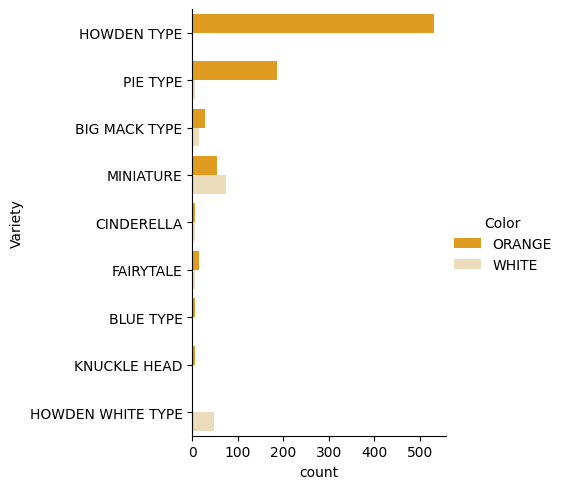

In [189]:
# Görselleştirme için seaborn kütüphanesini import etme
import seaborn as sns

# Renk paletini tanımlama
palette = {
    'ORANGE': '#FFA500',
    'WHITE': 'wheat',
}

# Çeşit ve rennge göre sayı grafiği oluşturma
sns.catplot(
    data=pumpkins, y='Variety', hue='Color', kind='count',
    palette=palette
)

In [190]:
# Boyut kategorilerindeki benzersiz değerleri görüntüleme
pumpkins['Item Size'].unique()

array(['med', 'lge', 'sml', 'xlge', 'med-lge', 'jbo', 'exjbo'],
      dtype=object)

In [191]:
# Ordinal (sıralı) encoder için sklearn kütüphanesini import etme
from sklearn.preprocessing import OrdinalEncoder

# Boyut kategorilerini sıralı olarak tanımlama (küçükten büyüğe)
item_size_categories = [['sml', 'med', 'med-lge', 'lge', 'xlge', 'jbo', 'exjbo']]
# Ordinal encode edilecek özelliği belirtme
ordinal_features = ['Item Size']
# Ordinal encoder oluşturma
ordinal_encoder = OrdinalEncoder(categories=item_size_categories)

In [192]:
# Kategorik özellikler için OneHotEncoder kullanma
from sklearn.preprocessing import OneHotEncoder

# One-hot encode edilecek kategorik özellikleri belirtme
categorical_features = ['City Name', 'Package', 'Variety', 'Origin']
# Sparse matrix yerine dense array çıktısı için OneHotEncoder oluşturma
categorical_encoder = OneHotEncoder(sparse_output=False)

In [193]:
# Farklı encoder'ları birleştirmek için ColumnTransformer kullanma
from sklearn.compose import ColumnTransformer

# Ordinal ve kateggorik encoder'ları birleştiren transformer oluşturma
ct = ColumnTransformer(transformers=[
    ('ord', ordinal_encoder, ordinal_features),
    ('cat', categorical_encoder, categorical_features)
])

# Çıktıyı pandas DataFrame formatında ayarlama
ct.set_output(transform='pandas')
# Özellikleri encode etme
encoded_features = ct.fit_transform(pumpkins)
encoded_features.head()

,ord__Item Size,cat__City Name_ATLANTA,cat__City Name_BALTIMORE,cat__City Name_BOSTON,cat__City Name_CHICAGO,cat__City Name_COLUMBIA,cat__City Name_DALLAS,cat__City Name_DETROIT,cat__City Name_LOS ANGELES,cat__City Name_MIAMI,...,cat__Origin_MICHIGAN,cat__Origin_NEW JERSEY,cat__Origin_NEW YORK,cat__Origin_NORTH CAROLINA,cat__Origin_OHIO,cat__Origin_PENNSYLVANIA,cat__Origin_TENNESSEE,cat__Origin_TEXAS,cat__Origin_VERMONT,cat__Origin_VIRGINIA
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [194]:
# Hedef değişken için LabelEncoder import etme
from sklearn.preprocessing import LabelEncoder

# Label encoder oluşturma ve renk sütununu encode etme
label_encoder = LabelEncoder()
encoded_label = label_encoder.fit_transform(pumpkins['Color'])
# Encode edilmiş hedef değişkeni özelliklere ekleme
encoded_pumpkins = encoded_features.assign(Color=encoded_label)
encoded_pumpkins.head()

,ord__Item Size,cat__City Name_ATLANTA,cat__City Name_BALTIMORE,cat__City Name_BOSTON,cat__City Name_CHICAGO,cat__City Name_COLUMBIA,cat__City Name_DALLAS,cat__City Name_DETROIT,cat__City Name_LOS ANGELES,cat__City Name_MIAMI,...,cat__Origin_NEW JERSEY,cat__Origin_NEW YORK,cat__Origin_NORTH CAROLINA,cat__Origin_OHIO,cat__Origin_PENNSYLVANIA,cat__Origin_TENNESSEE,cat__Origin_TEXAS,cat__Origin_VERMONT,cat__Origin_VIRGINIA,Color
2,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
5,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
6,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [195]:
# Encode edilmiş etiketlerin orijinal hallerini görme (0: ORANGE, 1: WHITE)
list(label_encoder.inverse_transform([0, 1]))

['ORANGE', 'WHITE']

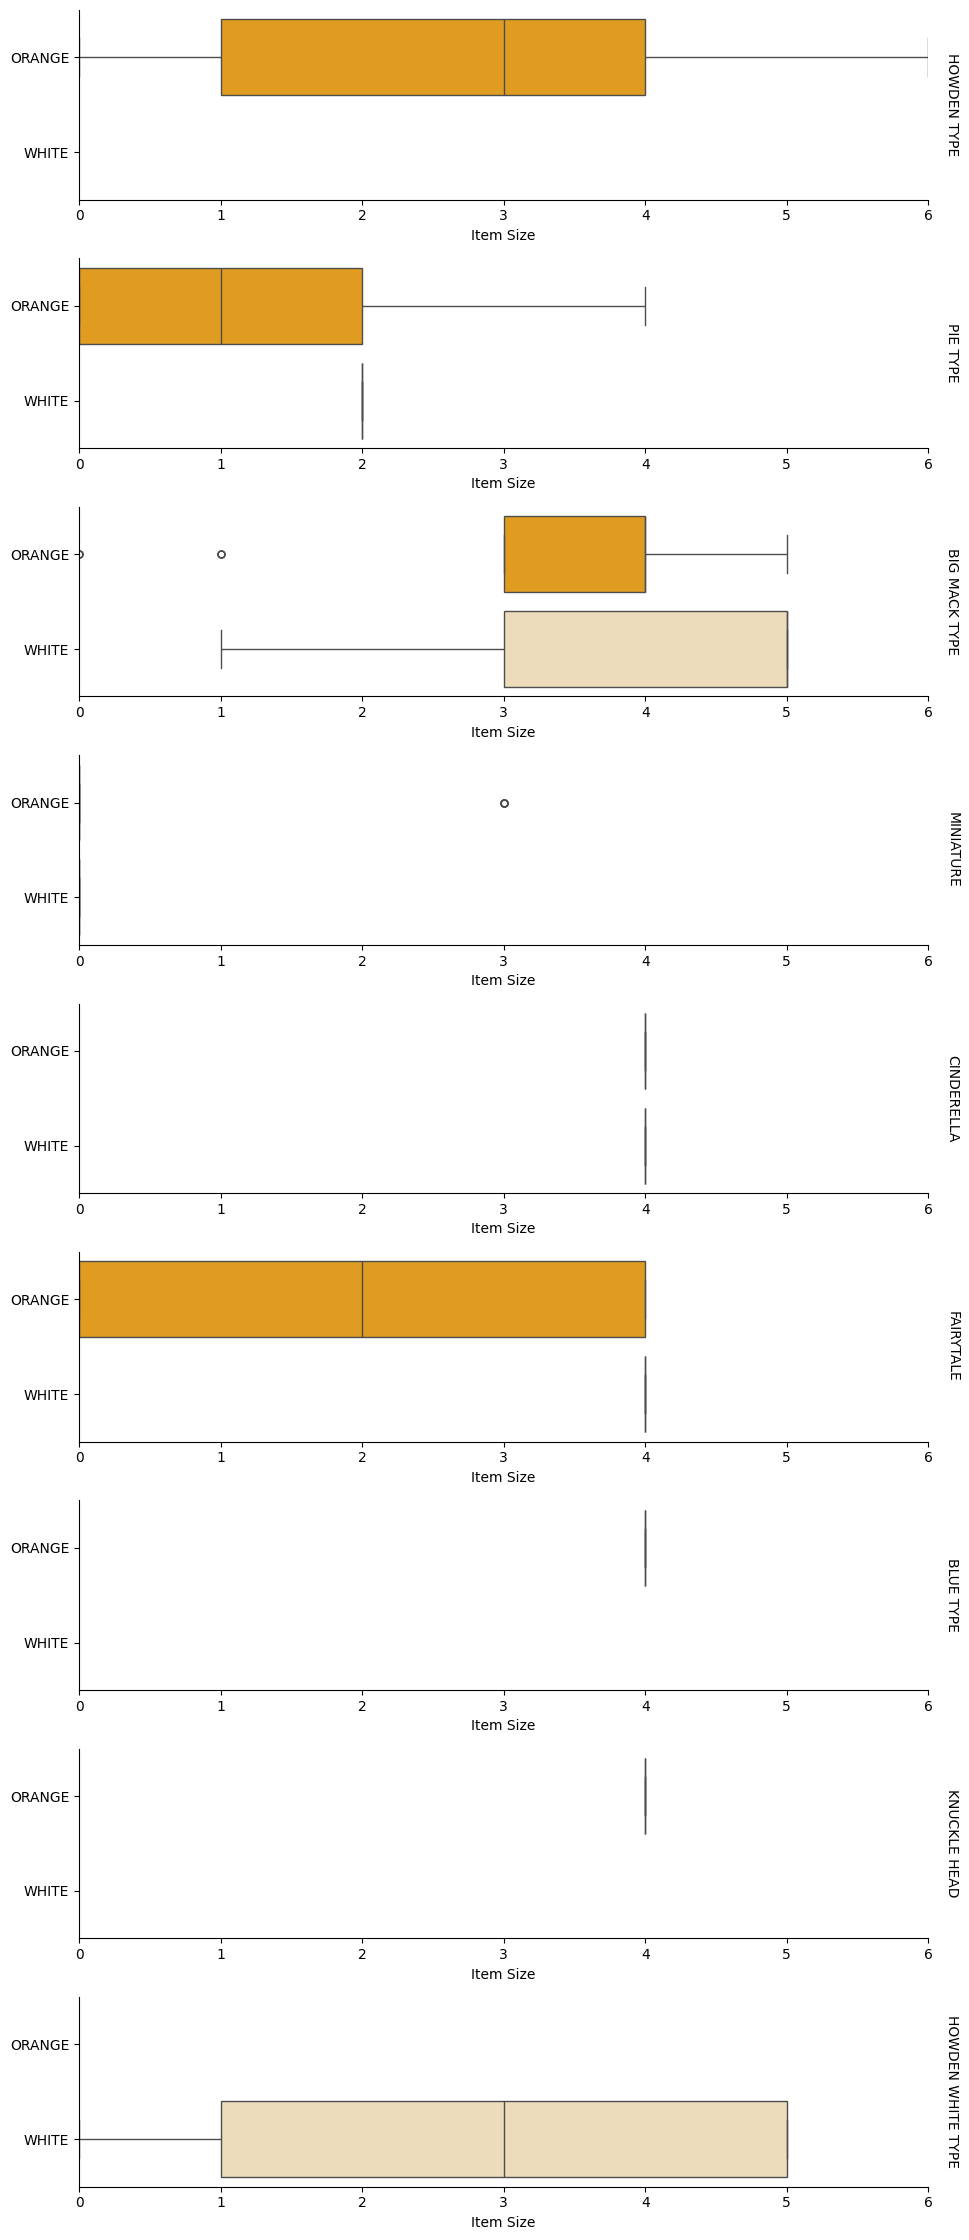

In [196]:
# Görselleştirme için renk paleti tanımlama
palette = {
    'ORANGE': 'orange',
    'WHITE': 'wheat',
}

# Orijinal veri setindeki Item Size'ı encode edilmiş değerlerle güncelleme
pumpkins['Item Size'] = encoded_pumpkins['ord__Item Size']

# Çeşit, boyut ve renge göre box plot oluşturma
g = sns.catplot(
    data=pumpkins, x='Item Size', y='Color', row='Variety',
    kind='box', orient='h', hue='Color',
    sharex=False, margin_titles=True,
    height=2.5, aspect=4, palette=palette
)

# Grafik ayarları
g.set(xlabel='Item Size', ylabel='').set(xlim=(0, 6))
g.set_titles(row_template='{row_name}')

<Axes: xlabel='Color', ylabel='ord__Item Size'>

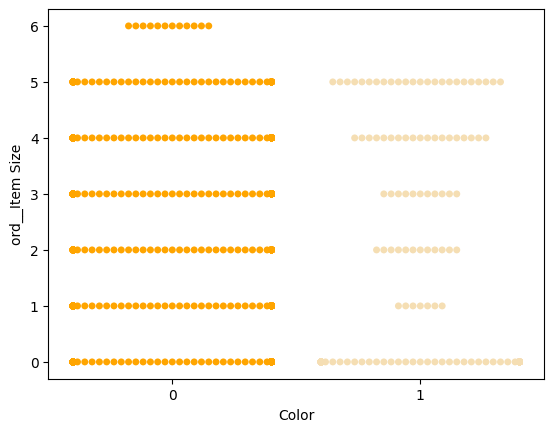

In [197]:
import warnings
warnings.filterwarnings('ignore')

# Encode edilmiş veriler için renk paleti (0: turuncu, 1: beyaz)
palette = {
    0: 'orange',
    1: 'wheat',
}

# Renk ve boyut ilişkisini gösteren swarm plot
sns.swarmplot(x='Color', y='ord__Item Size', data=encoded_pumpkins, hue='Color', palette=palette, legend=False)

In [198]:
# Train-test split için sklearn kütüphanesini import etme
from sklearn.model_selection import train_test_split

# Özellik matrisi (X): Color sütunu hariç tüm sütunlar
X = encoded_pumpkins[encoded_pumpkins.columns.difference(['Color'])]

# Hedef değişken (y): Color sütunu
y = encoded_pumpkins['Color']

In [199]:
# Veriyi %80 eğitim, %20 test olarak ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [200]:
# Model değerlendirme metrikleri ve lojistik regresyon import etme
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression

# Lojistik regresyon modeli oluşturma ve eğitme
model = LogisticRegression()
model.fit(X_train, y_train)
# Test verisi üzerinde tahmin yapma
pred = model.predict(X_test)

In [201]:
# Model performansını değerlendirme
print(classification_report(y_test, pred))
print(f"Predicted Labels: {pred}")
print(f"F1-score: {f1_score(y_test, pred)}")

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       166
           1       0.85      0.67      0.75        33

    accuracy                           0.92       199
   macro avg       0.89      0.82      0.85       199
weighted avg       0.92      0.92      0.92       199

Predicted Labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0
 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 1 0 0 0 0 0 0 0 0 1 1]
F1-score: 0.7457627118644068


## Precision (Kesinlik)

### Macro Avg:
Her class'ın precision değeri eşit ağırlıklı olarak ortalanır:

(0.94 + 0.85) / 2 = **0.895**

### Weighted Avg:
Her class'ın precision değeri, veri kümesindeki oranına göre ağırlıklı olarak hesaplanır:

- Class 0 (turuncu): 166 / (166 + 33) = **0.83** → Verilerin %83’ü  
- Class 1 (beyaz): 33 / (166 + 33) = **0.17** → Verilerin %17’si
  
(0.83 × 0.94) + (0.17 × 0.85) = **0.9247**


In [202]:
# Confusion matrix için import
from sklearn.metrics import confusion_matrix

# Karışıklık matrisi oluşturma
confusion_matrix(y_test, pred)

array([[162,   4],
       [ 11,  22]])

# Confusion Matrix ve Metrikler

## Confusion Matrix (Gerçek etiketler satırlarda - Actual, tahminler sütunlarda - Predicted)

```
               Predicted
              0        1
Actual  0    TN       FP
        1    FN       TP
```

| Terim | Açıklama |
|-------|----------|
| **TP (True Positive)** | Gerçek sınıf 1, tahmin edilen sınıf da 1 |
| **TN (True Negative)** | Gerçek sınıf 0, tahmin edilen sınıf da 0 |
| **FP (False Positive)** | Gerçek sınıf 0, tahmin edilen sınıf 1 (Yanlış alarm) |
| **FN (False Negative)** | Gerçek sınıf 1, tahmin edilen sınıf 0 (Kaçırma) |

## Metrix Hesaplamaları

**Accuracy (Doğruluk)**  
Modelin tüm doğru tahminlerinin oranı:  
`(TP + TN) / (TP + TN + FP + FN)`

**Precision (Kesinlik)**  
Pozitif tahminlerin ne kadarının doğru olduğunu gösterir:  
`TP / (TP + FP)`

**Recall (Duyarlılık / Tespit Oranı)**  
Gerçek pozitiflerin ne kadarının doğru tahmin edildiğini gösterir:  
`TP / (TP + FN)`

**F1-Score**  
Precision ve Recall’un harmonik ortalamasıdır:  
`2 * (Precision * Recall) / (Precision + Recall)`


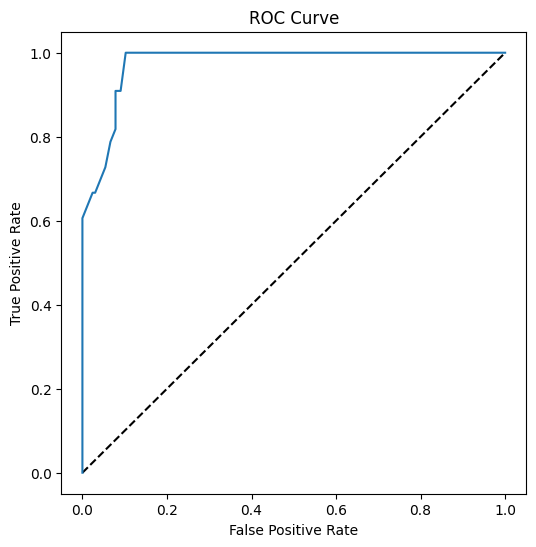

In [203]:
# ROC eğrisi ve AUC metrikleri için import
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
%matplotlib inline

# Model tarafından tahmin edilen olasılıkları alma
y_scores = model.predict_proba(X_test)
# ROC eğrisi için gerekli değerleri hesaplama
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:, 1])

# ROC eğrisi çizme
fig = plt.figure(figsize=(6, 6))

# Referans çizgisi (diagonal)
plt.plot([0, 1], [0, 1], 'k--')

# ROC eğrisi
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

In [204]:
# AUC (Area Under Curve) skorunu hesaplama
auc = roc_auc_score(y_test, y_scores[:, 1])
print(f"AUC: {auc}")

AUC: 0.9749908725812341


In [205]:
# F1 skorunu tekrar yazdırma
print(f"F1 Score: {f1_score(y_test, pred)}")

F1 Score: 0.7457627118644068


In [206]:
# Sınıflandırma raporunu tekrar yazdırma
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       166
           1       0.85      0.67      0.75        33

    accuracy                           0.92       199
   macro avg       0.89      0.82      0.85       199
weighted avg       0.92      0.92      0.92       199



In [207]:
# Threshold optimizasyonu için gerekli metrikleri import etme
from sklearn.metrics import precision_score, recall_score
# Denenmek üzere threshold değerlerini belirleme (0.1'den 0.9'a 0.05 aralıklarla)
thresholds_to_try = np.arange(0.1, 0.9, 0.05)
# En iyi F1 skoru ve threshold'u takip etmek için değişkenler
best_f1 = 0
best_threshold = 0.5
# Sonuçları saklamak için liste
results = []

In [208]:
# Farklı threshold değerlerini deneyerek en iyisini bulma
for thresholds in thresholds_to_try:
    # Belirtilen threshold'a göre tahmin yapma
    pred_thresh = (y_scores[:, 1] > thresholds).astype(int)
    # F1, precision ve recall skorlarını hesaplama
    f1 = f1_score(y_test, pred_thresh)
    precision = precision_score(y_test, pred_thresh)
    recall = recall_score(y_test, pred_thresh)
    # Sonuçları kaydetme
    results.append({
        'threshold': thresholds,
        'f1_score': f1,
        'precision': precision,
        'recall': recall
    })
    # En iyi F1 skorunu güncelleme
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresholds

print(f"En iyi thereshold: {best_threshold:.3f}")
print(f"En iyi F1 Skor: {best_f1:.3f}")

En iyi thereshold: 0.250
En iyi F1 Skor: 0.795


In [209]:
# En iyi threshold ile yeni tahminler yapma
best_pred = (y_scores[:, 1] > best_threshold).astype(int)

# Eski ve yeni F1 skorlarını karşılaştırma
print(f"Eski F1 Skor: {f1_score(y_test, pred):.3f}")
print(f"Yeni F1 Skor: {f1_score(y_test, best_pred):.3f}")
print(f"İyileşme: +{(f1_score(y_test, best_pred) - f1_score(y_test, pred)):.3f}")

Eski F1 Skor: 0.746
Yeni F1 Skor: 0.795
İyileşme: +0.049


In [210]:
# Optimize edilmiş threshold ile elde edilen karışıklık matrisi
confusion_matrix(y_test, best_pred)

array([[149,  17],
       [  0,  33]])